# **Data Visualization and Analysis**

In this section, we perform a comprehensive analysis of the paleobiological dataset focusing on the Dinosauria and Pterosauria taxons. The analysis aims to uncover patterns, trends, and insights regarding the diversity, distribution, and evolutionary history of these ancient species.

***Geographical Analysis***: Using the coordinates of fossil findings, we map the geographical spread of species, revealing hotspots of paleobiological activity and potential correlations with ancient environmental conditions.

***Species Distribution***: We analyze the distribution of species across different taxonomic orders, periods, and geographical locations. Visualizations such as bar charts, pie charts, and maps are employed to highlight diversity and prevalence within these groups.

- **Analyze Basal Species for orders, superorders, and infraorders (look at max MYA)**
- **Analyze Genus, Order, and Fossil Occ Distribution**
- **etc.**

***Temporal Analysis***: By examining the first and last appearances of species, we create timelines to track the evolutionary lifespan and extinction patterns. This helps to identify periods of significant biodiversity or extinction events.

***Lifespan Analysis***: The analysis of species lifespans across different orders and periods provides insights into the survival and adaptation strategies of these taxa. Statistical comparisons and visual summaries are used to present the findings.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import folium as fm
import requests as rq
import geopandas as gpd
import io

In [10]:
# Importing the species and genera dataframes from the Data Collection Notebook to use in this one
%run dino_collection.ipynb

species.head()

,Species,Genus,Family,Infraorder,Suborder,Order,Diet,Early Age,Late Age,Early Period,Late Period,Max MYA,Min MYA,Lifespan (MYA)
0,Ajkaceratops kozmai,Ajkaceratops,,,,Ornithischia,Herbivore,Santonian,Santonian,Upper Cretaceous,Upper Cretaceous,86.3,83.6,2.7
1,Turanoceratops tardabilis,Turanoceratops,,,,Ornithischia,Herbivore,Turonian,Turonian,Upper Cretaceous,Upper Cretaceous,93.9,89.8,4.1
2,Zuniceratops christopheri,Zuniceratops,,,,Ornithischia,Herbivore,Turonian,Turonian,Upper Cretaceous,Upper Cretaceous,93.9,89.8,4.1
3,Bagaceratops rozhdestvenskyi,Bagaceratops,Protoceratopsidae,,,Ornithischia,Herbivore,Campanian,Campanian,Upper Cretaceous,Upper Cretaceous,83.6,72.1,11.5
4,Breviceratops kozlowskii,Breviceratops,Protoceratopsidae,,,Ornithischia,Herbivore,Campanian,Campanian,Upper Cretaceous,Upper Cretaceous,83.6,72.1,11.5


## **Geographical Analysis**

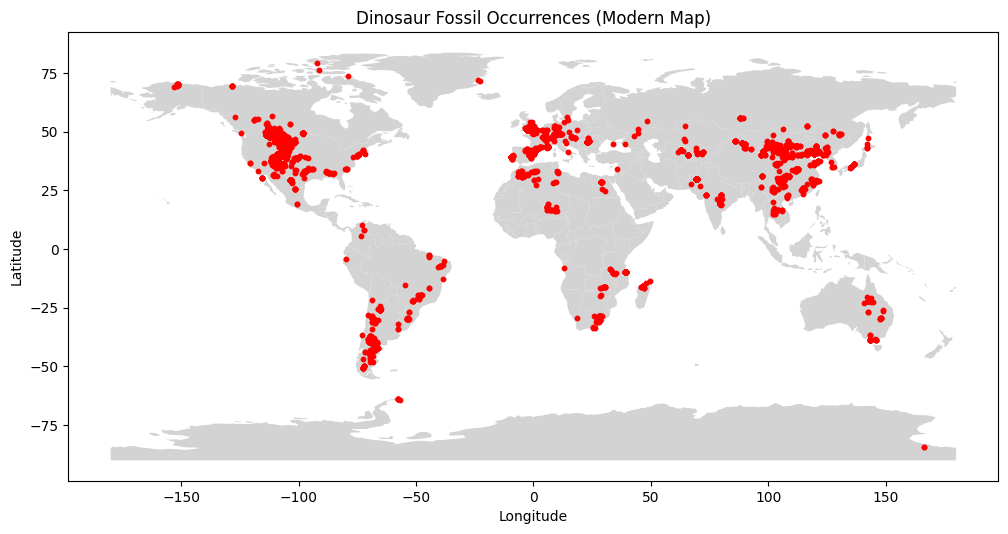

In [11]:
world = gpd.read_file('../data-reserve/ne_110m_admin_0_countries.shx')

fossil_plot = gpd.GeoDataFrame(occ, geometry=gpd.points_from_xy(occ['Longitude'], occ['Latitude']))

fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color="lightgrey")
fossil_plot.plot(ax=ax, markersize=10, color="red", alpha=1)
plt.title("Dinosaur Fossil Occurrences (Modern Map)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### **Genera and Species Distribution**
The first items I want to showcase are basic categorical graphs. In doing this, we can establish a solid foundation of Dinosauria's population distribution.

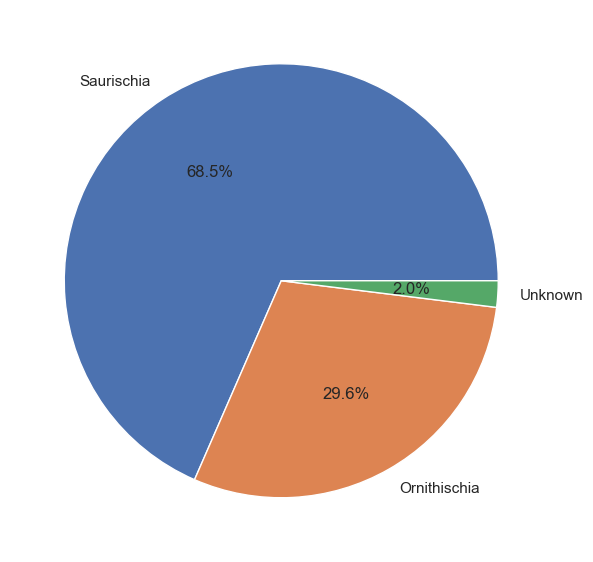

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(7,10))

# Modify the Species dataframe in the other notebook to fix the omnivore, piscivore, and insectivore
order_data = species['Order'].fillna('Unknown').value_counts(dropna=False).to_dict()
order_data['Unknown'] += order_data['']
order_data[''] = 0
        
order_data = { k:v for k,v in order_data.items() if v>0 }

ax.pie(x=order_data.values(), labels=order_data.keys(), autopct='%1.1f%%');

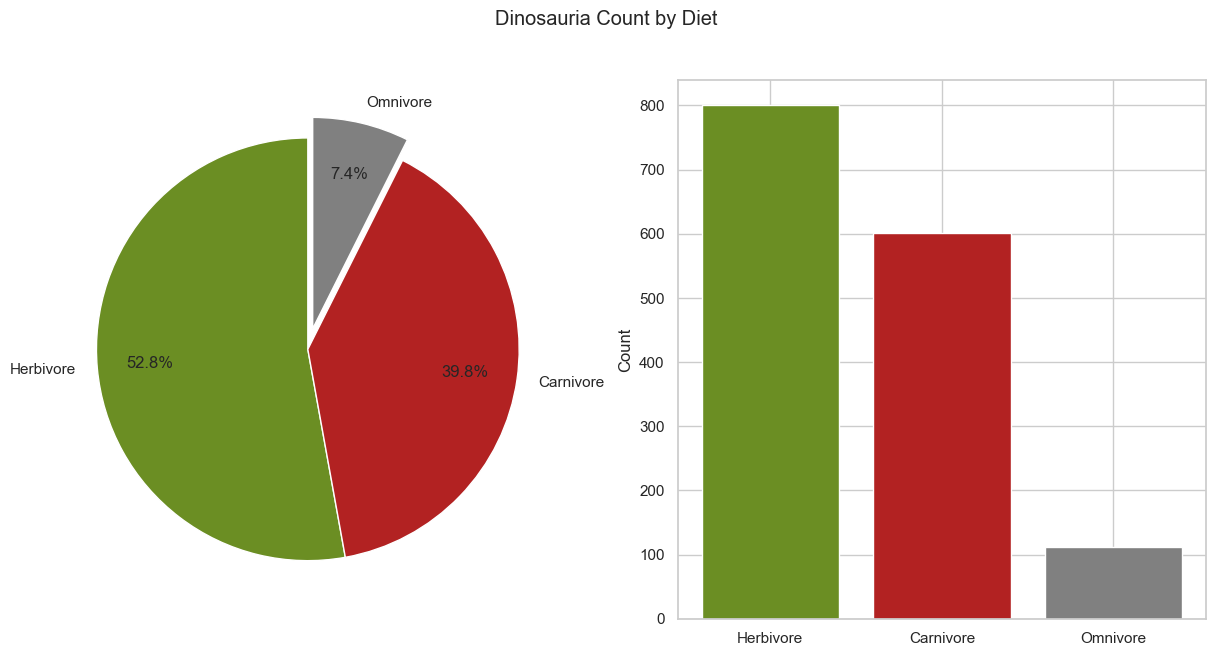

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Modify the Species dataframe in the other notebook to fix the omnivore, piscivore, and insectivore
diet_data = species['Diet'].value_counts(dropna=True).to_dict()

chart_colors=['olivedrab', 'firebrick', 'gray']

for i in diet_data:
   
    if 'omnivore' in i:
        diet_data['Omnivore'] += diet_data[i]
        diet_data[i] = 0
                
    elif 'Piscivore' in i or 'insectivore' in i:
        diet_data['Carnivore'] += diet_data[i]
        diet_data[i] = 0
        
diet_data = { k:v for k,v in diet_data.items() if v>0 }

ax1.pie(x=diet_data.values(), labels=diet_data.keys(),  autopct='%1.1f%%', explode=(0,0,0.1), pctdistance=0.75, colors=chart_colors, startangle=90);
ax2.bar(x=diet_data.keys(), height=diet_data.values(), color=chart_colors);
ax2.set_ylabel('Count')
fig.suptitle("Dinosauria Count by Diet");
